 # Accuracy Validation: Vectorized vs Scalar (geopack) Implementations



 Purpose of this notebook:

 - Quantify how much the vectorized implementation differs from the original (scalar) `geopack`

 - Help users judge whether the vectorized version is **safe to use** for their applications

 - Automatically diagnose whether discrepancies are due to:

   (1) benign floating-point effects (evaluation-order / rounding),

   (2) algorithmic differences (e.g., convergence stopping criteria),

   (3) out-of-range inputs / boundary behavior.



 Notes:

 - This is an **implementation-to-implementation** comparison, not validation against observations.

 - For complex external field models, physical/model uncertainty is typically far larger than ~1e-6 nT

   implementation differences.



 Outputs:

 - PASS/WARN/FAIL per function/model, with percentile metrics (p99||ΔB|| etc.)

 - Diagnostics for WARN/FAIL external models (worst point + batch dependence test)

 - Summary table including Coordinate / Models / IGRF (domain-separated)

In [1]:
# 0) Imports / Environment
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopack
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

print("Python / NumPy info")
import sys
print("  python:", sys.version.split()[0])
print("  numpy :", np.__version__)
print("  float eps:", np.finfo(np.float64).eps)


Load IGRF coefficients ...
Python / NumPy info
  python: 3.11.1
  numpy : 2.2.6
  float eps: 2.220446049250313e-16


In [2]:
# 1) Initialize geopack
# ---------------------------------------------------------
ut = datetime(2020, 1, 1, 12, 0, 0).timestamp()
ps = geopack.recalc(ut)
print("ps (tilt) =", ps)

np.random.seed(42)



ps (tilt) = -0.5451500462386779


 ## 2) Configuration

 Adjust these if you want faster runs or stricter thresholds.

In [3]:
# Number of points
COORD_N = 2000
MODEL_N = 2000

# Coordinate transforms should match near machine precision
STRICT_COORD_ABS = 1e-14

# Practical tolerances for external field models:
# PASS: comfortably small differences
# WARN: still small and usually negligible, but above the PASS target
# FAIL: likely algorithmic mismatch, dtype issue, or out-of-domain usage
MODEL_TOLS = {
    "T89": {"abs_pass": 1e-12, "rel_pass": 1e-12, "abs_warn": 1e-10, "rel_warn": 1e-10},
    "T96": {"abs_pass": 1e-7,  "rel_pass": 2e-9,  "abs_warn": 1e-6,  "rel_warn": 2e-8},
    "T01": {"abs_pass": 1e-7,  "rel_pass": 2e-9,  "abs_warn": 1e-6,  "rel_warn": 2e-8},
    "T04": {"abs_pass": 5e-7,  "rel_pass": 2e-9,  "abs_warn": 2e-6,  "rel_warn": 2e-8},
}

# Batch-size dependence threshold:
# If the vectorized result for the same point changes depending on batch size above this,
# it suggests an algorithmic mismatch (e.g., global convergence stopping).
BATCH_FAIL = 1e-10

# IGRF tolerances (deterministic; should match tightly in typical domain)
IGRF_TOLS = {
    "abs_pass": 1e-10,  # nT
    "rel_pass": 1e-12,
    "abs_warn": 1e-8,   # nT
    "rel_warn": 1e-10,
}

# IGRF domains (user-facing):
# Typical: near Earth to moderate distances
# Extended: optional wider range (still r>=1 Re)
IGRF_DOMAINS = {
    "typical": {"rmin": 1.0, "rmax": 20.0, "n": 4000},
    "extended": {"rmin": 1.0, "rmax": 60.0, "n": 4000},  # optional
}



 ## 3) Utilities: metrics and reporting

In [4]:
def stack3(res):
    """(bx,by,bz) -> (n,3) array"""
    bx, by, bz = res
    return np.stack([np.asarray(bx), np.asarray(by), np.asarray(bz)], axis=-1)

def safe_norm(v):
    return np.linalg.norm(v, axis=-1)

def compute_error_stats(Bs, Bv, rel_floor=1e-12):
    """
    Bs, Bv: (n,3) arrays
    """
    Bs = np.asarray(Bs, dtype=np.float64)
    Bv = np.asarray(Bv, dtype=np.float64)

    d = Bs - Bv
    abs_comp = np.abs(d)
    dnorm = safe_norm(d)
    Bnorm = safe_norm(Bs)

    rel = np.zeros_like(dnorm)
    m = Bnorm > rel_floor
    rel[m] = dnorm[m] / Bnorm[m]

    eps = np.finfo(np.float64).eps
    eps_scaled = eps * np.maximum(1.0, Bnorm)
    eps_ratio = dnorm / np.maximum(eps_scaled, 1e-300)

    return {
        "d": d,
        "abs_comp": abs_comp,
        "dnorm": dnorm,
        "Bnorm": Bnorm,
        "rel": rel,
        "eps_ratio": eps_ratio,
        "max_abs_comp": float(abs_comp.max()),
        "max_dnorm": float(dnorm.max()),
        "mean_dnorm": float(dnorm.mean()),
        "max_rel": float(rel.max()) if np.any(m) else 0.0,
        "mean_rel": float(rel[m].mean()) if np.any(m) else 0.0,
        "p50_dnorm": float(np.quantile(dnorm, 0.50)),
        "p90_dnorm": float(np.quantile(dnorm, 0.90)),
        "p99_dnorm": float(np.quantile(dnorm, 0.99)),
        "p999_dnorm": float(np.quantile(dnorm, 0.999)),
        "max_eps_ratio": float(eps_ratio.max()),
        "p99_eps_ratio": float(np.quantile(eps_ratio, 0.99)),
    }

def worst_points_table(x, y, z, Bs, Bv, st, k=10):
    idx = np.argsort(-st["dnorm"])[:k]
    df = pd.DataFrame({
        "i": idx,
        "x": x[idx], "y": y[idx], "z": z[idx],
        "Bx_s": Bs[idx,0], "By_s": Bs[idx,1], "Bz_s": Bs[idx,2],
        "Bx_v": Bv[idx,0], "By_v": Bv[idx,1], "Bz_v": Bv[idx,2],
        "dBx": st["d"][idx,0], "dBy": st["d"][idx,1], "dBz": st["d"][idx,2],
        "||dB||": st["dnorm"][idx],
        "rel": st["rel"][idx],
        "eps_ratio": st["eps_ratio"][idx],
    })
    return df

def status_from_tols(name, st):
    tol = MODEL_TOLS[name]
    if (st["max_abs_comp"] <= tol["abs_pass"]) and (st["max_rel"] <= tol["rel_pass"]):
        return "PASS"
    if (st["max_abs_comp"] <= tol["abs_warn"]) and (st["max_rel"] <= tol["rel_warn"]):
        return "WARN"
    return "FAIL"

def igrf_status(st, batch_max=None):
    if (st["max_abs_comp"] <= IGRF_TOLS["abs_pass"]) and (st["max_rel"] <= IGRF_TOLS["rel_pass"]):
        return "PASS"
    if (st["max_abs_comp"] <= IGRF_TOLS["abs_warn"]) and (st["max_rel"] <= IGRF_TOLS["rel_warn"]):
        return "WARN"
    if batch_max is not None and batch_max <= BATCH_FAIL and st["max_rel"] <= 1e-8:
        return "WARN (numeric order)"
    return "FAIL"

def get_func(obj, name):
    return getattr(obj, name, None)



 ## 4) Test point generators

In [ ]:
def gen_cartesian_points(n=2000, box=20.0, include_edge=True):
    pts = []
    if include_edge:
        pts.extend([
            (1e-10, 1e-10, 1e-10),
            (1.0, 0.0, 0.0),
            (0.0, 1.0, 0.0),
            (0.0, 0.0, 1.0),
            (-1.0, 0.0, 0.0),
            (0.0, -1.0, 0.0),
            (0.0, 0.0, -1.0),
        ])
    m = n - len(pts)
    if m > 0:
        x = np.random.uniform(-box, box, m)
        y = np.random.uniform(-box, box, m)
        z = np.random.uniform(-box, box, m)
        pts.extend(list(zip(x, y, z)))
    return pts[:n]

def gen_spherical_angles(n=2000):
    pts = []
    pts.extend([
        (0.0, 0.0, 0.0),
        (np.pi, 0.0, 0.0),
        (np.pi/2, 0.0, 0.0),
        (np.pi/2, np.pi/2, 0.0),
        (np.pi/2, np.pi, 0.0),
        (np.pi/2, 3*np.pi/2, 0.0),
    ])
    m = n - len(pts)
    if m > 0:
        th = np.random.uniform(0, np.pi, m)
        ph = np.random.uniform(0, 2*np.pi, m)
        dummy = np.zeros(m)
        pts.extend(list(zip(th, ph, dummy)))
    return pts[:n]

def gen_model_points(n=2000, seed=42):
    """
    Model test points:
    - Respect typical usage domain for T01/T04: x > -15
    """
    rng = np.random.default_rng(seed)
    n4 = n // 4

    # Near Earth
    r = rng.uniform(2, 10, n4)
    th = rng.uniform(0, np.pi, n4)
    ph = rng.uniform(0, 2*np.pi, n4)
    x1 = r*np.sin(th)*np.cos(ph)
    y1 = r*np.sin(th)*np.sin(ph)
    z1 = r*np.cos(th)

    # Tail (x>-15)
    x2 = rng.uniform(-14.9, -5, n4)
    y2 = rng.uniform(-10, 10, n4)
    z2 = rng.uniform(-5, 5, n4)

    # Dayside
    x3 = rng.uniform(5, 15, n4)
    y3 = rng.uniform(-10, 10, n4)
    z3 = rng.uniform(-10, 10, n4)

    # Random (x>-15)
    m = n - 3*n4
    x4 = rng.uniform(-14.9, 15, m)
    y4 = rng.uniform(-15, 15, m)
    z4 = rng.uniform(-15, 15, m)

    x = np.concatenate([x1,x2,x3,x4]).astype(np.float64)
    y = np.concatenate([y1,y2,y3,y4]).astype(np.float64)
    z = np.concatenate([z1,z2,z3,z4]).astype(np.float64)
    return x, y, z

# IGRF generators
def gen_igrf_cart_points(n=4000, rmin=1.0, rmax=10.0, seed=123, include_edge=True):
    """
    Sample points uniformly in direction, with r uniform in [rmin, rmax].
    Returns x,y,z (float64).
    """
    rng = np.random.default_rng(seed)
    u = rng.uniform(-1.0, 1.0, n)           # cos(theta)
    phi = rng.uniform(0.0, 2*np.pi, n)
    r = rng.uniform(rmin, rmax, n)

    st = np.sqrt(np.maximum(0.0, 1.0 - u*u))
    x = r * st * np.cos(phi)
    y = r * st * np.sin(phi)
    z = r * u

    if include_edge:
        edge = np.array([
            [rmin, 0.0, 0.0],
            [-rmin, 0.0, 0.0],
            [0.0, rmin, 0.0],
            [0.0, -rmin, 0.0],
            [0.0, 0.0, rmin],
            [0.0, 0.0, -rmin],
            [1e-6, 1e-6, 1e-6],  # tiny but non-zero
        ], dtype=np.float64)
        x[:len(edge)] = edge[:,0]
        y[:len(edge)] = edge[:,1]
        z[:len(edge)] = edge[:,2]

    return x.astype(np.float64), y.astype(np.float64), z.astype(np.float64)

def gen_igrf_sph_points(n=4000, rmin=1.0, rmax=10.0, seed=456, include_edge=True):
    """
    Generate spherical points (r, theta, phi). Include poles explicitly.
    """
    rng = np.random.default_rng(seed)
    r = rng.uniform(rmin, rmax, n)
    theta = rng.uniform(0.0, np.pi, n)
    phi = rng.uniform(0.0, 2*np.pi, n)

    if include_edge:
        edge = np.array([
            [rmin, 0.0, 0.0],           # north pole
            [rmin, np.pi, 0.0],         # south pole
            [rmin, np.pi/2, 0.0],       # equator
            [rmin, np.pi/2, np.pi/2],
            [rmin, np.pi/2, np.pi],
            [rmin, np.pi/2, 3*np.pi/2],
        ], dtype=np.float64)
        r[:len(edge)] = edge[:,0]
        theta[:len(edge)] = edge[:,1]
        phi[:len(edge)] = edge[:,2]

    return r.astype(np.float64), theta.astype(np.float64), phi.astype(np.float64)



 ## 5) Coordinate Transformation Accuracy (strict)

 Coordinate transforms should match near machine precision.


Coordinate Transformation Accuracy
Function        max_abs      max_rel   Status
gsmgse         0.00e+00     0.00e+00     PASS
geigeo         0.00e+00     0.00e+00     PASS
magsm          0.00e+00     0.00e+00     PASS
smgsm          0.00e+00     0.00e+00     PASS
geomag         0.00e+00     0.00e+00     PASS
geogsm         0.00e+00     0.00e+00     PASS
gswgsm         0.00e+00     0.00e+00     PASS
sphcar         0.00e+00     0.00e+00     PASS
bspcar         0.00e+00     0.00e+00     PASS
bcarsp         3.33e-16     2.01e-16     PASS


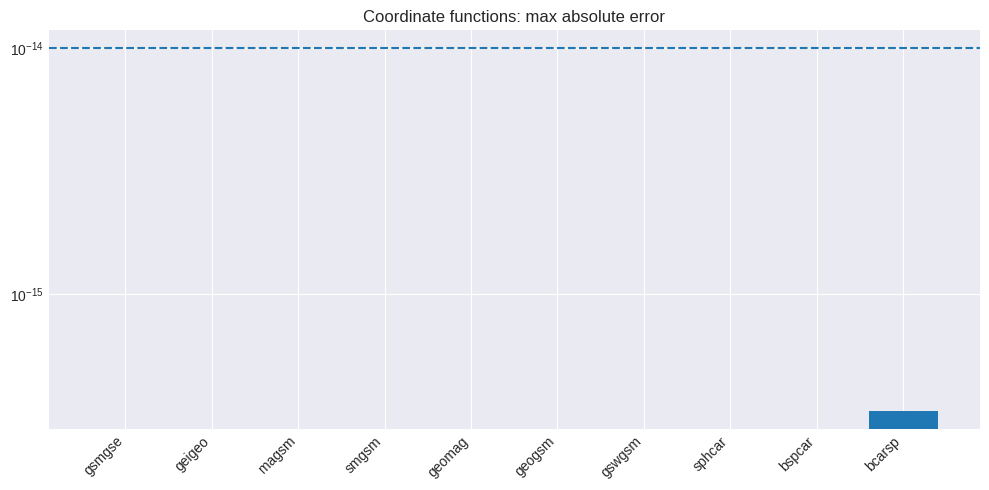

In [6]:
coord_pts = gen_cartesian_points(COORD_N, box=20.0, include_edge=True)
sph_pts = gen_spherical_angles(COORD_N)

coord_functions = [
    ("gsmgse", geopack.gsmgse, geopack.gsmgse_vectorized, "coord"),
    ("geigeo", geopack.geigeo, geopack.geigeo_vectorized, "coord"),
    ("magsm",  geopack.magsm,  geopack.magsm_vectorized,  "coord"),
    ("smgsm",  geopack.smgsm,  geopack.smgsm_vectorized,  "coord"),
    ("geomag", geopack.geomag, geopack.geomag_vectorized, "coord"),
    ("geogsm", geopack.geogsm, geopack.geogsm_vectorized, "coord"),
    ("gswgsm", geopack.gswgsm, geopack.gswgsm_vectorized, "coord"),
    ("sphcar", geopack.sphcar, geopack.sphcar_vectorized, "coord"),
    ("bspcar", geopack.bspcar, geopack.bspcar_vectorized, "bspcar"),
    ("bcarsp", geopack.bcarsp, geopack.bcarsp_vectorized, "bcarsp"),
]

def eval_scalar_coord(func, pts, ftype):
    out = np.empty((len(pts), 3), dtype=np.float64)
    for i,(x,y,z) in enumerate(pts):
        if ftype == "coord":
            out[i,:] = func(float(x), float(y), float(z), 1)
        elif ftype == "bspcar":
            th, ph = float(x), float(y)
            out[i,:] = func(th, ph, 1.0, 0.5, 0.3)
        elif ftype == "bcarsp":
            out[i,:] = func(float(x), float(y), float(z),
                            float(x)*0.1, float(y)*0.1, float(z)*0.1)
    return out

def eval_vector_coord(func, pts, ftype):
    x = np.array([p[0] for p in pts], dtype=np.float64)
    y = np.array([p[1] for p in pts], dtype=np.float64)
    z = np.array([p[2] for p in pts], dtype=np.float64)
    if ftype == "coord":
        return stack3(func(x,y,z,1)).astype(np.float64)
    if ftype == "bspcar":
        th, ph = x, y
        br = np.full_like(th, 1.0)
        bt = np.full_like(th, 0.5)
        bp = np.full_like(th, 0.3)
        return stack3(func(th, ph, br, bt, bp)).astype(np.float64)
    if ftype == "bcarsp":
        return stack3(func(x,y,z, x*0.1, y*0.1, z*0.1)).astype(np.float64)
    raise ValueError(ftype)

coord_results = {}

print("\nCoordinate Transformation Accuracy")
print("="*80)
print(f"{'Function':10s} {'max_abs':>12s} {'max_rel':>12s} {'Status':>8s}")

for name, f_s, f_v, ftype in coord_functions:
    pts = sph_pts if name == "bspcar" else coord_pts
    Bs = eval_scalar_coord(f_s, pts, ftype)
    Bv = eval_vector_coord(f_v, pts, ftype)
    st = compute_error_stats(Bs, Bv, rel_floor=1e-15)
    coord_results[name] = st

    status = "PASS" if st["max_abs_comp"] < STRICT_COORD_ABS else "FAIL"
    print(f"{name:10s} {st['max_abs_comp']:12.2e} {st['max_rel']:12.2e} {status:>8s}")

plt.figure(figsize=(10,5))
names = list(coord_results.keys())
vals = [coord_results[k]["max_abs_comp"] for k in names]
plt.bar(names, vals)
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Coordinate functions: max absolute error")
plt.axhline(STRICT_COORD_ABS, linestyle="--")
plt.tight_layout()
plt.show()



 ## 6) Magnetic Field Model Accuracy (practical)



 For complex external field models, vectorization can change evaluation order.

 We care about whether differences remain **practically negligible**.



 We also run a **batch-size dependence test** when a model would otherwise FAIL:

 - If the same point changes when computed in a batch, suspect algorithmic mismatch.

 - If batch dependence is ~0, and the relative error is tiny, it is typically just numeric order/rounding.


Magnetic Field Model Accuracy
Model       max_abs      max_rel    p99||dB||               Status
T89        2.84e-14     3.99e-15     1.42e-14                 PASS
T96        4.53e-08     9.80e-10     1.55e-08                 PASS
T01        3.30e-08     9.48e-10     2.05e-09                 PASS
T04        1.83e-07     5.44e-09     5.70e-09                 WARN


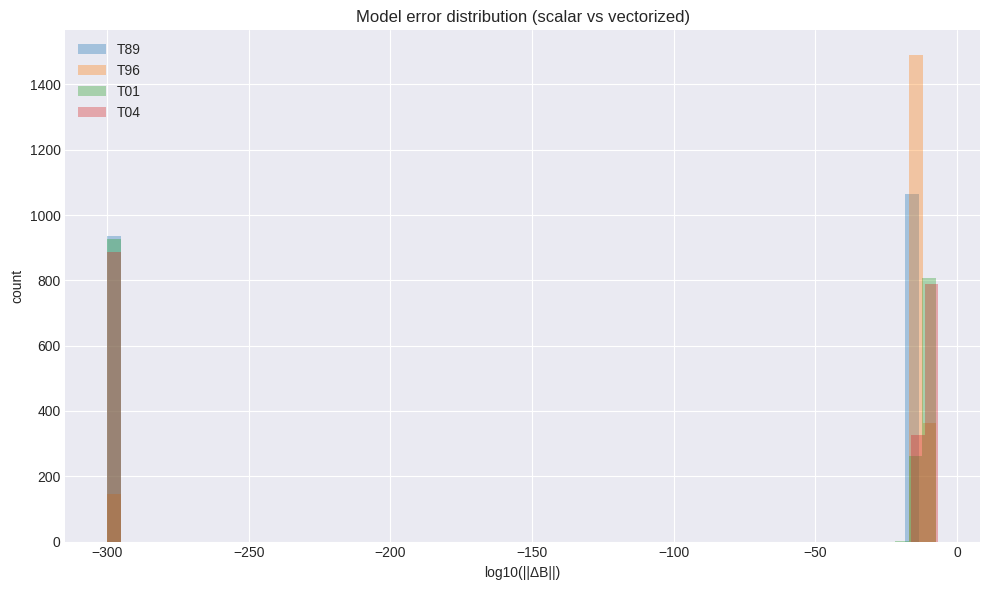

In [ ]:
x, y, z = gen_model_points(MODEL_N, seed=42)

parmod_default = np.zeros(10, dtype=np.float64)
parmod_default[0] = 3.0    # Pdyn
parmod_default[1] = -20.0  # Dst
parmod_default[2] = 0.0    # ByIMF
parmod_default[3] = -5.0   # BzIMF

parmod_t01 = parmod_default.copy()
parmod_t01[4] = 2.0
parmod_t01[5] = 3.0

parmod_t04 = parmod_default.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

model_functions = [
    ("T89", geopack.t89, geopack.t89_vectorized, 4),
    ("T96", geopack.t96, geopack.t96_vectorized, parmod_default),
    ("T01", geopack.t01, geopack.t01_vectorized, parmod_t01),
    ("T04", geopack.t04, geopack.t04_vectorized, parmod_t04),
]

def eval_scalar_model(func, params, x,y,z):
    out = np.empty((len(x), 3), dtype=np.float64)
    for i in range(len(x)):
        bx,by,bz = func(params, ps, float(x[i]), float(y[i]), float(z[i]))
        out[i,:] = (bx,by,bz)
    return out

def eval_vector_model(funcv, params, x,y,z):
    bx,by,bz = funcv(params, ps,
                     np.asarray(x, dtype=np.float64),
                     np.asarray(y, dtype=np.float64),
                     np.asarray(z, dtype=np.float64))
    return stack3((bx,by,bz)).astype(np.float64)

def batch_dependence_test_model(vec_func, params, x0,y0,z0, trials=5, batch_n=500):
    x0 = float(x0); y0 = float(y0); z0 = float(z0)
    bx,by,bz = vec_func(params, ps,
                        np.array([x0],dtype=np.float64),
                        np.array([y0],dtype=np.float64),
                        np.array([z0],dtype=np.float64))
    B_single = np.array([float(bx[0]), float(by[0]), float(bz[0])], dtype=np.float64)

    diffs = []
    for t in range(trials):
        xb, yb, zb = gen_model_points(batch_n, seed=1000+t)
        xb[0], yb[0], zb[0] = x0, y0, z0
        bx,by,bz = vec_func(params, ps,
                            xb.astype(np.float64), yb.astype(np.float64), zb.astype(np.float64))
        B_batch = np.array([float(bx[0]), float(by[0]), float(bz[0])], dtype=np.float64)
        diffs.append(float(np.max(np.abs(B_batch - B_single))))
    return B_single, diffs, float(np.max(diffs))

model_results = {}
model_status = {}
model_batchmax = {}

print("\nMagnetic Field Model Accuracy")
print("="*90)
print(f"{'Model':6s} {'max_abs':>12s} {'max_rel':>12s} {'p99||dB||':>12s} {'Status':>20s}")

for name, f_s, f_v, params in model_functions:
    Bs = eval_scalar_model(f_s, params, x,y,z)
    Bv = eval_vector_model(f_v, params, x,y,z)
    st = compute_error_stats(Bs, Bv, rel_floor=1e-12)

    base = status_from_tols(name, st)
    status = base
    batch_max = None

    if base == "FAIL":
        i0 = int(np.argmax(st["dnorm"]))
        x0,y0,z0 = float(x[i0]), float(y[i0]), float(z[i0])
        _, _, batch_max = batch_dependence_test_model(f_v, params, x0,y0,z0, trials=5)
        if batch_max <= BATCH_FAIL and st["max_rel"] <= MODEL_TOLS[name]["rel_warn"]:
            status = "WARN (numeric order)"
        elif batch_max > BATCH_FAIL:
            status = "FAIL (batch dependent)"
        else:
            status = "FAIL"

    model_results[name] = (st, Bs, Bv)
    model_status[name] = status
    model_batchmax[name] = batch_max

    print(f"{name:6s} {st['max_abs_comp']:12.2e} {st['max_rel']:12.2e} {st['p99_dnorm']:12.2e} {status:>20s}")

plt.figure(figsize=(10,6))
for name in ["T89","T96","T01","T04"]:
    st, _, _ = model_results[name]
    plt.hist(np.log10(st["dnorm"] + 1e-300), bins=60, alpha=0.35, label=name)
plt.xlabel("log10(||ΔB||)")
plt.ylabel("count")
plt.title("Model error distribution (scalar vs vectorized)")
plt.legend()
plt.tight_layout()
plt.show()



 ## 7) IGRF Accuracy (domain-separated)



 IGRF is deterministic (spherical harmonics), with no iteration/convergence logic.

 Therefore, **batch-size dependence should be ~0**. Nonzero batch dependence would indicate a bug.



 We evaluate IGRF in two domains:

 - `typical`: 1 <= r <= 20 Re (recommended usage band for this notebook)

 - `extended`: 1 <= r <= 60 Re (optional, still physically meaningful for internal field comparisons)



 We test:

 - IGRF_GEO: (r, theta, phi) -> (Br, Btheta, Bphi)   [if available]

 - IGRF_GSM: (x, y, z) -> (Bx, By, Bz)

 - IGRF_GSW: (x, y, z) -> (Bx, By, Bz)


IGRF Accuracy
Domain     Test            max_abs      max_rel    p99||dB||    batch_max             Status
typical    IGRF_GEO       0.00e+00     0.00e+00     0.00e+00     0.00e+00               PASS
typical    IGRF_GSM       3.27e-11     1.44e-15     4.84e-12     0.00e+00               PASS
typical    IGRF_GSW       3.64e-11     1.34e-15     4.07e-12     0.00e+00               PASS
extended   IGRF_GEO       0.00e+00     0.00e+00     0.00e+00     0.00e+00               PASS
extended   IGRF_GSM       4.37e-11     1.37e-15     7.84e-13     0.00e+00               PASS
extended   IGRF_GSW       4.37e-11     1.29e-15     1.23e-12     0.00e+00               PASS


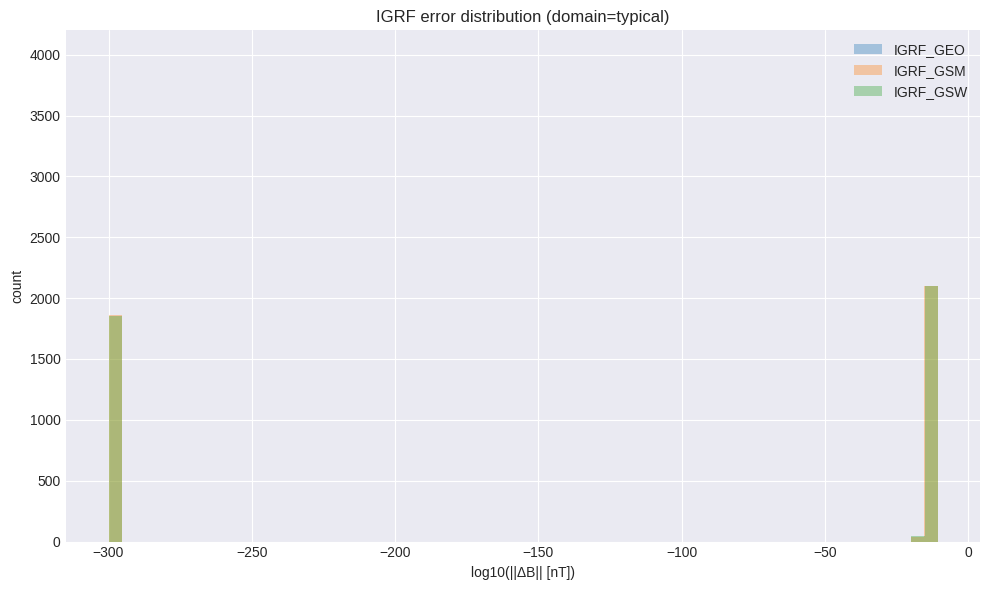

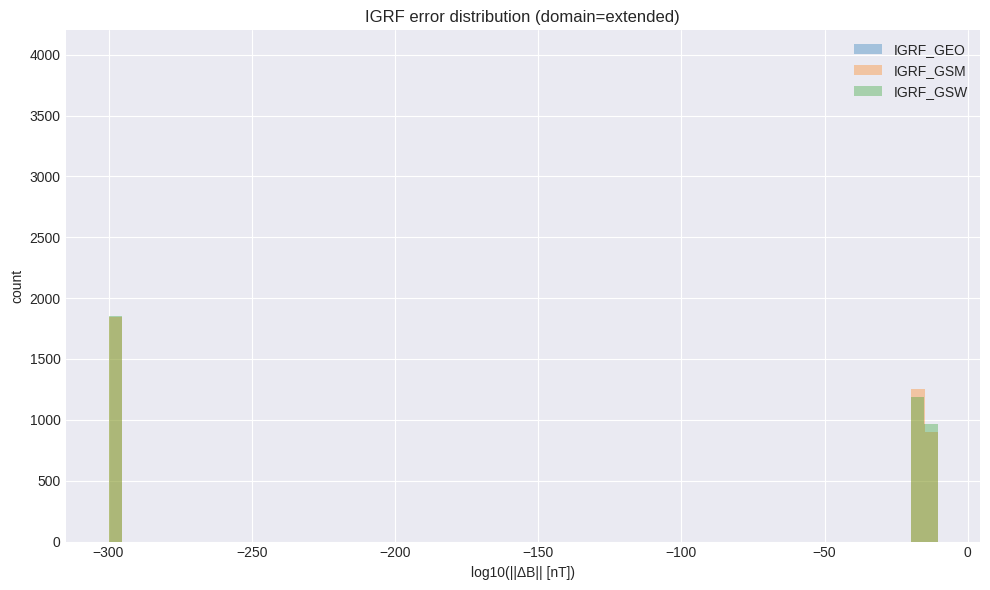


IGRF takeaway:
   typical IGRF_GEO: max_abs=0.00e+00 nT, max_rel=0.00e+00, p99||dB||=0.00e+00, batch_max=0.00e+00 -> PASS
   typical IGRF_GSM: max_abs=3.27e-11 nT, max_rel=1.44e-15, p99||dB||=4.84e-12, batch_max=0.00e+00 -> PASS
   typical IGRF_GSW: max_abs=3.64e-11 nT, max_rel=1.34e-15, p99||dB||=4.07e-12, batch_max=0.00e+00 -> PASS
  extended IGRF_GEO: max_abs=0.00e+00 nT, max_rel=0.00e+00, p99||dB||=0.00e+00, batch_max=0.00e+00 -> PASS
  extended IGRF_GSM: max_abs=4.37e-11 nT, max_rel=1.37e-15, p99||dB||=7.84e-13, batch_max=0.00e+00 -> PASS
  extended IGRF_GSW: max_abs=4.37e-11 nT, max_rel=1.29e-15, p99||dB||=1.23e-12, batch_max=0.00e+00 -> PASS


In [ ]:
igrf_candidates = [
    ("IGRF_GEO", "igrf_geo", "igrf_geo_vectorized", "sph"),
    ("IGRF_GSM", "igrf_gsm", "igrf_gsm_vectorized", "car"),
    ("IGRF_GSW", "igrf_gsw", "igrf_gsw_vectorized", "car"),
]

def eval_scalar_igrf_car(func, x, y, z):
    out = np.empty((len(x), 3), dtype=np.float64)
    for i in range(len(x)):
        bx, by, bz = func(float(x[i]), float(y[i]), float(z[i]))
        out[i, :] = (bx, by, bz)
    return out

def eval_vector_igrf_car(funcv, x, y, z):
    bx, by, bz = funcv(x.astype(np.float64), y.astype(np.float64), z.astype(np.float64))
    return stack3((bx, by, bz)).astype(np.float64)

def eval_scalar_igrf_sph(func, r, theta, phi):
    out = np.empty((len(r), 3), dtype=np.float64)
    for i in range(len(r)):
        br, bt, bf = func(float(r[i]), float(theta[i]), float(phi[i]))
        out[i, :] = (br, bt, bf)
    return out

def eval_vector_igrf_sph(funcv, r, theta, phi):
    br, bt, bf = funcv(r.astype(np.float64), theta.astype(np.float64), phi.astype(np.float64))
    return stack3((br, bt, bf)).astype(np.float64)

def batch_dependence_test_igrf(vec_func, coord_type, x0):
    if coord_type == "car":
        x, y, z = x0
        bx,by,bz = vec_func(np.array([x],dtype=np.float64),
                            np.array([y],dtype=np.float64),
                            np.array([z],dtype=np.float64))
        B_single = np.array([float(bx[0]), float(by[0]), float(bz[0])], dtype=np.float64)

        diffs = []
        for t in range(5):
            xb, yb, zb = gen_igrf_cart_points(n=500, rmin=1.0, rmax=20.0, seed=9000+t, include_edge=False)
            xb[0], yb[0], zb[0] = x, y, z
            bx,by,bz = vec_func(xb, yb, zb)
            B_batch = np.array([float(bx[0]), float(by[0]), float(bz[0])], dtype=np.float64)
            diffs.append(float(np.max(np.abs(B_batch - B_single))))
        return float(np.max(diffs))

    if coord_type == "sph":
        r, th, ph = x0
        br,bt,bf = vec_func(np.array([r],dtype=np.float64),
                            np.array([th],dtype=np.float64),
                            np.array([ph],dtype=np.float64))
        B_single = np.array([float(br[0]), float(bt[0]), float(bf[0])], dtype=np.float64)

        diffs = []
        for t in range(5):
            rb, thb, phb = gen_igrf_sph_points(n=500, rmin=1.0, rmax=20.0, seed=9100+t, include_edge=False)
            rb[0], thb[0], phb[0] = r, th, ph
            br,bt,bf = vec_func(rb, thb, phb)
            B_batch = np.array([float(br[0]), float(bt[0]), float(bf[0])], dtype=np.float64)
            diffs.append(float(np.max(np.abs(B_batch - B_single))))
        return float(np.max(diffs))

    raise ValueError(coord_type)

igrf_results = {}

print("\nIGRF Accuracy")
print("="*98)
print(f"{'Domain':10s} {'Test':10s} {'max_abs':>12s} {'max_rel':>12s} {'p99||dB||':>12s} {'batch_max':>12s} {'Status':>18s}")

for domain_name, dom in IGRF_DOMAINS.items():
    rmin = dom["rmin"]; rmax = dom["rmax"]; npts = dom["n"]

    for label, scalar_name, vec_name, ctype in igrf_candidates:
        f_s = get_func(geopack, scalar_name)
        f_v = get_func(geopack, vec_name)

        if f_s is None or f_v is None:
            print(f"{domain_name:10s} {label:10s}  SKIP (missing: {scalar_name} or {vec_name})")
            continue

        if ctype == "car":
            xi, yi, zi = gen_igrf_cart_points(n=npts, rmin=rmin, rmax=rmax, seed=123, include_edge=True)
            Bs = eval_scalar_igrf_car(f_s, xi, yi, zi)
            Bv = eval_vector_igrf_car(f_v, xi, yi, zi)
            st = compute_error_stats(Bs, Bv, rel_floor=1e-12)

            i0 = int(np.argmax(st["dnorm"]))
            batch_max = batch_dependence_test_igrf(f_v, "car", (float(xi[i0]), float(yi[i0]), float(zi[i0])))

        elif ctype == "sph":
            rr, th, ph = gen_igrf_sph_points(n=npts, rmin=rmin, rmax=rmax, seed=456, include_edge=True)
            Bs = eval_scalar_igrf_sph(f_s, rr, th, ph)
            Bv = eval_vector_igrf_sph(f_v, rr, th, ph)
            st = compute_error_stats(Bs, Bv, rel_floor=1e-12)

            i0 = int(np.argmax(st["dnorm"]))
            batch_max = batch_dependence_test_igrf(f_v, "sph", (float(rr[i0]), float(th[i0]), float(ph[i0])))

        else:
            raise ValueError(ctype)

        status = igrf_status(st, batch_max=batch_max)
        key = f"{domain_name}:{label}"
        igrf_results[key] = {"domain": domain_name, "label": label, "stats": st, "status": status, "batch_max": batch_max}

        print(f"{domain_name:10s} {label:10s} {st['max_abs_comp']:12.2e} {st['max_rel']:12.2e} "
              f"{st['p99_dnorm']:12.2e} {batch_max:12.2e} {status:>18s}")

# Plot IGRF distributions per domain
if len(igrf_results) > 0:
    for domain_name in IGRF_DOMAINS.keys():
        plt.figure(figsize=(10,6))
        for key, pack in igrf_results.items():
            if pack["domain"] != domain_name:
                continue
            st = pack["stats"]
            plt.hist(np.log10(st["dnorm"] + 1e-300), bins=60, alpha=0.35, label=pack["label"])
        plt.xlabel("log10(||ΔB|| [nT])")
        plt.ylabel("count")
        plt.title(f"IGRF error distribution (domain={domain_name})")
        plt.legend()
        plt.tight_layout()
        plt.show()

print("\nIGRF takeaway:")
if len(igrf_results) == 0:
    print("  IGRF: (not evaluated / missing functions)")
else:
    for key, pack in igrf_results.items():
        st = pack["stats"]
        print(f"  {pack['domain']:>8s} {pack['label']:>8s}: "
              f"max_abs={st['max_abs_comp']:.2e} nT, max_rel={st['max_rel']:.2e}, "
              f"p99||dB||={st['p99_dnorm']:.2e}, batch_max={pack['batch_max']:.2e} -> {pack['status']}")



 ## 8) Diagnostics for WARN / FAIL (external models)



 For each WARN/FAIL external model, we print:

 - worst point and its field difference

 - batch-size dependence test (vectorized-only)



 Interpretation:

 - If batch dependence is ~0 and relative error is tiny, it often indicates evaluation-order/rounding effects.

 - If batch dependence is large, suspect an algorithmic mismatch.

In [ ]:
# Helper dicts for diagnostics
vec_by_name = dict((m[0], m[2]) for m in model_functions)
par_by_name = dict((m[0], m[3]) for m in model_functions)

for name, (st, Bs, Bv) in model_results.items():
    status = model_status[name]
    if status == "PASS":
        continue

    print("\n" + "="*90)
    print(f"Diagnostics for {name}  (status={status})")

    i0 = int(np.argmax(st["dnorm"]))
    x0,y0,z0 = float(x[i0]), float(y[i0]), float(z[i0])

    print("worst index:", i0)
    print("pos:", (x0,y0,z0))
    print("B_scalar:", Bs[i0])
    print("B_vec   :", Bv[i0])
    print("diff    :", st["d"][i0], " ||dB||=", float(st["dnorm"][i0]), " rel=", float(st["rel"][i0]))

    B_single, diffs, batch_max = batch_dependence_test_model(
        vec_by_name[name], par_by_name[name], x0,y0,z0, trials=5, batch_n=500
    )
    print("\nBatch-size dependence (vectorized only):")
    print("B(single):", B_single)
    print("max|B(batch)-B(single)|:", diffs, "  max=", batch_max)




Diagnostics for T04  (status=WARN)
worst index: 1573
pos: (-7.189604638245466, 0.17201061553066488, 10.88180439788804)
B_scalar: [45.05360599  0.14047325 -7.5006797 ]
B_vec   : [45.05360617  0.14047317 -7.50067956]
diff    : [-1.83413320e-07  7.95561035e-08 -1.47762472e-07]  ||dB||= 2.486028315522141e-07  rel= 5.442992616630717e-09

Batch-size dependence (vectorized only):
B(single): [45.05360617  0.14047317 -7.50067956]
max|B(batch)-B(single)|: [0.0, 0.0, 0.0, 0.0, 0.0]   max= 0.0


 ## 9) Summary Table (for users)



 Status interpretation:

 - PASS: differences are comfortably small (for typical scientific use).

 - WARN: differences are larger than PASS, but still small and typically negligible.

 - WARN (numeric order): thresholds would have failed, but batch dependence is ~0 and rel error is tiny,

   indicating evaluation-order/rounding effects rather than an algorithmic mismatch.

 - FAIL (batch dependent): vectorized output for the same point changes with batch -> likely algorithmic mismatch.



 IGRF interpretation:

 - IGRF is deterministic (no iteration). Batch dependence should be ~0; nonzero suggests a bug.

 - In the typical domain (1 <= r <= 20 Re), we expect near machine-precision agreement.

In [ ]:
rows = []

# Coordinate functions
for name, st in coord_results.items():
    rows.append({
        "Function": name,
        "Type": "Coordinate",
        "Domain": "",
        "Status": "PASS" if st["max_abs_comp"] < STRICT_COORD_ABS else "FAIL",
        "max_abs": st["max_abs_comp"],
        "max_rel": st["max_rel"],
        "p99||dB||": st["p99_dnorm"],
        "batch_max": None,
    })

# External field models
for name, (st, _, _) in model_results.items():
    rows.append({
        "Function": name,
        "Type": "Model",
        "Domain": "",
        "Status": model_status[name],
        "max_abs": st["max_abs_comp"],
        "max_rel": st["max_rel"],
        "p99||dB||": st["p99_dnorm"],
        "batch_max": model_batchmax.get(name, None),
    })

# IGRF (domain-separated)
if "igrf_results" in globals() and len(igrf_results) > 0:
    for key, pack in igrf_results.items():
        st = pack["stats"]
        rows.append({
            "Function": pack["label"],
            "Type": "IGRF",
            "Domain": pack["domain"],
            "Status": pack["status"],
            "max_abs": st["max_abs_comp"],
            "max_rel": st["max_rel"],
            "p99||dB||": st["p99_dnorm"],
            "batch_max": pack["batch_max"],
        })

# --- Add explicit units ---
def infer_unit(row):
    if row["Type"] in ("Model", "IGRF"):
        return "nT"
    if row["Type"] == "Coordinate":
        return "mixed"   # coordinate transforms mix Re/rad/etc.
    return ""

df_summary = pd.DataFrame(rows).sort_values(["Type", "Domain", "Function"])
df_summary["Unit"] = df_summary.apply(infer_unit, axis=1)

# Reorder columns to show unit prominently
cols = ["Type", "Domain", "Function", "Unit", "Status", "max_abs", "max_rel", "p99||dB||", "batch_max"]
cols = [c for c in cols if c in df_summary.columns]
df_summary = df_summary[cols]

display(df_summary)

print("\nOverall highlights:")
print("  Coordinate max abs:", max(coord_results[k]["max_abs_comp"] for k in coord_results))
print("  Models max abs     :", max(model_results[k][0]["max_abs_comp"] for k in model_results))
print("  Models max rel     :", max(model_results[k][0]["max_rel"] for k in model_results))

if "igrf_results" in globals() and len(igrf_results) > 0:
    max_igrf_abs = max(pack["stats"]["max_abs_comp"] for pack in igrf_results.values())
    max_igrf_rel = max(pack["stats"]["max_rel"] for pack in igrf_results.values())
    print("  IGRF max abs       :", max_igrf_abs)
    print("  IGRF max rel       :", max_igrf_rel)
else:
    print("  IGRF: (not evaluated / missing functions)")



,Type,Domain,Function,Unit,Status,max_abs,max_rel,p99||dB||,batch_max
9,Coordinate,,bcarsp,mixed,PASS,3.330669e-16,2.014105e-16,0.000000e+00,NaN
8,Coordinate,,bspcar,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
1,Coordinate,,geigeo,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
5,Coordinate,,geogsm,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
4,Coordinate,,geomag,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
0,Coordinate,,gsmgse,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
6,Coordinate,,gswgsm,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
2,Coordinate,,magsm,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
3,Coordinate,,smgsm,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN
7,Coordinate,,sphcar,mixed,PASS,0.000000e+00,0.000000e+00,0.000000e+00,NaN



Overall highlights:
  Coordinate max abs: 3.3306690738754696e-16
  Models max abs     : 1.8341332008731115e-07
  Models max rel     : 5.442992616630717e-09
  IGRF max abs       : 4.3655745685100555e-11
  IGRF max rel       : 1.4415903031255464e-15


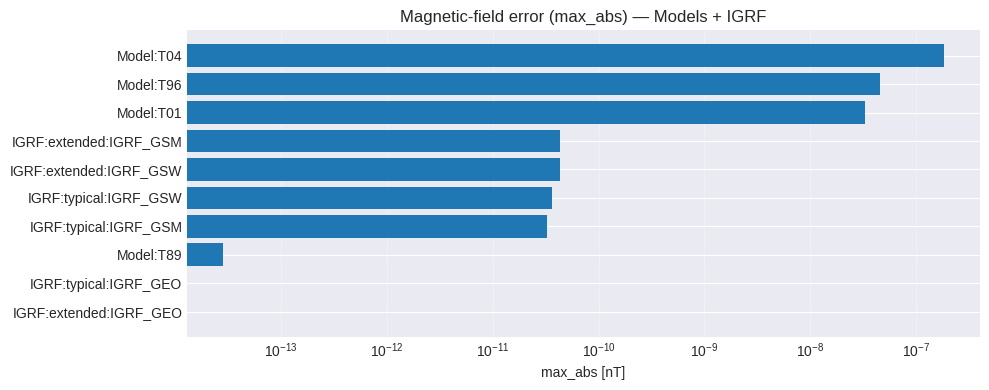

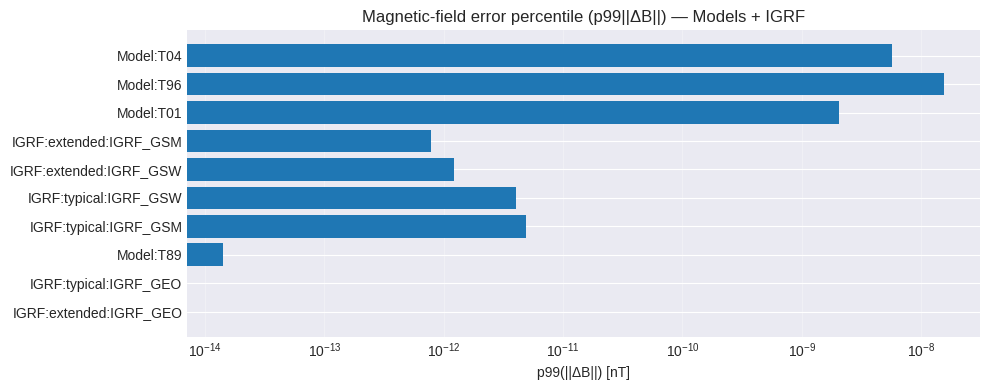

In [ ]:
# Plot only magnetic-field-type results (Models + IGRF)
df_B = df_summary[df_summary["Type"].isin(["Model", "IGRF"])].copy()

if len(df_B) == 0:
    print("No magnetic-field results found (Model/IGRF).")
else:
    df_B["label"] = df_B.apply(
        lambda r: f"{r['Type']}:{r['Domain']}:{r['Function']}" if r["Domain"] else f"{r['Type']}:{r['Function']}",
        axis=1
    )

    df_B = df_B.sort_values("max_abs", ascending=True)

    # (A) max_abs bar chart
    plt.figure(figsize=(10, max(4, 0.35*len(df_B))))
    plt.barh(df_B["label"], df_B["max_abs"])
    plt.xscale("log")
    plt.xlabel("max_abs [nT]")
    plt.title("Magnetic-field error (max_abs) — Models + IGRF")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    # (B) p99||dB|| bar chart
    plt.figure(figsize=(10, max(4, 0.35*len(df_B))))
    plt.barh(df_B["label"], df_B["p99||dB||"])
    plt.xscale("log")
    plt.xlabel("p99(||ΔB||) [nT]")
    plt.title("Magnetic-field error percentile (p99||ΔB||) — Models + IGRF")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()


 ## 10) Optional: Quick visual ranking by max_abs

 This plot is useful for a "one-glance" overview.

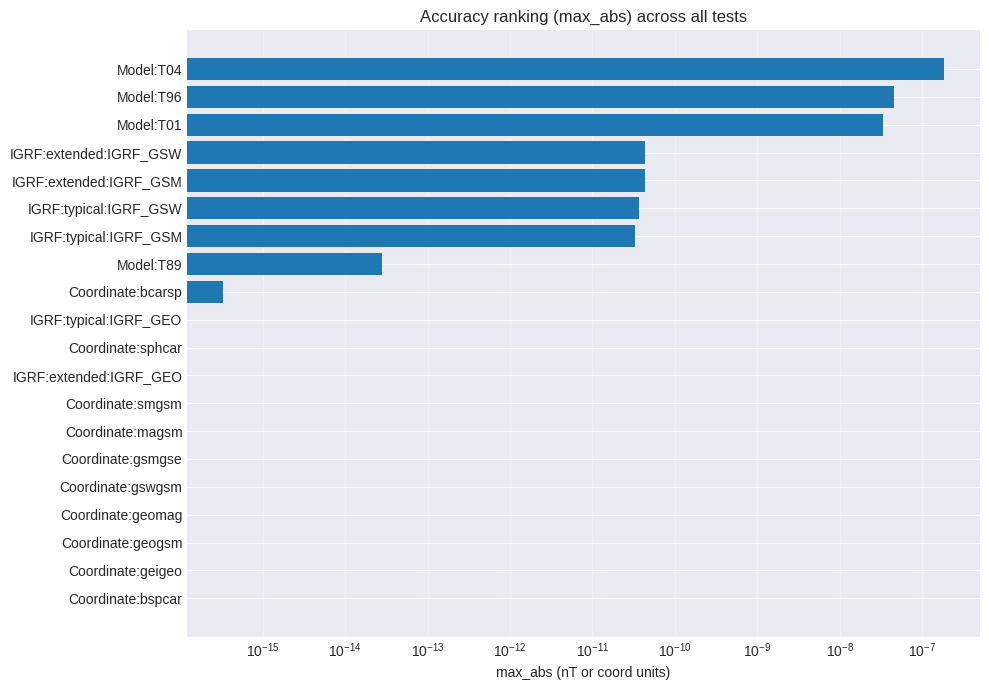

In [ ]:
df_plot = df_summary.copy()
df_plot["label"] = df_plot.apply(lambda r: f"{r['Type']}:{r['Domain']}:{r['Function']}" if r["Domain"] else f"{r['Type']}:{r['Function']}", axis=1)
df_plot = df_plot.sort_values("max_abs", ascending=True)

plt.figure(figsize=(10, max(4, 0.35*len(df_plot))))
plt.barh(df_plot["label"], df_plot["max_abs"])
plt.xscale("log")
plt.xlabel("max_abs (nT or coord units)")
plt.title("Accuracy ranking (max_abs) across all tests")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()
